# Experiment 01 — Per-move agreement matrix

Build a **square heatmap** with *per-move agreement* (move matching accuracy) between a selection of models.

**Agreement definition**
- Two models *agree* on a move in a row if their `fen_*` strings are exactly equal.

**Row selection**
A row is eligible iff:
`half_move > 20` and `((player_color == 'white' and half_move is odd) OR (player_color == 'black' and half_move is even))`.

**Input**: `data/processed/chess_fraud_synth_extended.csv"` (only `player_color`, `half_move`, and chosen `fen_*` columns are used).

**Outputs** (in `OUT_DIR`):
- `per_move_agreement_heatmap.png`

In [1]:
# === Imports / seeds ===
import os
import subprocess, sys
from pathlib import Path
import re
import random

import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from IPython.display import display

In [2]:
# === Paths / config ===
REPO_ROOT = "/home/jovyan/artem/chess-fraud"
print("REPO_ROOT:", REPO_ROOT)

INPUT_CSV = REPO_ROOT / Path("data/processed/chess_fraud_synth_extended.csv")
assert INPUT_CSV.exists(), f"Missing INPUT_CSV: {INPUT_CSV}"
print("INPUT_CSV:", INPUT_CSV)

OUT_DIR = REPO_ROOT / Path("reports/01_per_move_agreement")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

# Chunk size for streaming through ~1M rows without blowing RAM.
CHUNKSIZE = 200_000

REPO_ROOT: /home/jovyan/artem/chess-fraud
INPUT_CSV: /home/jovyan/artem/chess-fraud/data/processed/chess_fraud_synth_extended.csv
OUT_DIR: /home/jovyan/artem/chess-fraud/reports/01_per_move_agreement


In [3]:
# === Utilities ===
def select_eligible_rows(df: pd.DataFrame) -> pd.Series:
    """Eligibility mask (reused across experiments).

    Rule:
      half_move > 20 AND (
        (player_color == 'white' AND half_move % 2 == 1) OR
        (player_color == 'black' AND half_move % 2 == 0)
      )
    """
    half_move = df["half_move"].to_numpy()
    player_color = df["player_color"].astype("string")

    return (half_move > 20) & (
        ((player_color == "white") & (half_move % 2 == 1)) |
        ((player_color == "black") & (half_move % 2 == 0))
    )


def build_fen_col_to_model(columns: list[str]) -> dict[str, str]:
    """Map FEN columns to model names.

    Requirements:
      - fen_after -> human
      - all other fen_* (except fen_before) map by stripping 'fen_' prefix:
          fen_maia2_1850 -> maia2_1850
    """
    out: dict[str, str] = {}
    if "fen_after" in columns:
        out["fen_after"] = "human"

    for c in columns:
        if not c.startswith("fen_"):
            continue
        if c in ("fen_before", "fen_after"):
            continue
        out[c] = c.replace("fen_", "", 1)

    return out


def _model_sort_key(name: str) -> tuple:
    """Stable, human-friendly model ordering for tables/plots."""
    if name == "human":
        return (0, 0)

    m = re.match(r"^(maia1|maia2)_(\d+)$", name)
    if m:
        fam, r = m.group(1), int(m.group(2))
        return (1 if fam == "maia1" else 2, r)

    m = re.match(r"^lc0_(\d+)$", name)
    if m:
        return (3, int(m.group(1)))

    m = re.match(r"^stockfish_(\d+)$", name)
    if m:
        return (4, int(m.group(1)))

    return (5, name)


In [4]:
# === Agreement computation ===
def factorize_2d(values_2d: np.ndarray) -> np.ndarray:
    """Factorize a 2D object array jointly to integer codes.

    Returns:
      codes2d: int32 array, same shape.

    Notes:
      - We factorize per-chunk; global code consistency is NOT required for equality checks.
      - Missing values are NOT supported/handled here (guaranteed absent).
    """
    assert values_2d.ndim == 2
    flat = values_2d.ravel(order="C")
    codes, _uniques = pd.factorize(flat, sort=False)
    codes2d = codes.reshape(values_2d.shape).astype(np.int32, copy=False)
    return codes2d


def update_match_counts(match_counts: np.ndarray, *, codes: np.ndarray) -> None:
    """Accumulate pairwise matches for a chunk.

    match rule:
      codes[:, i] == codes[:, j]
    """
    n_rows, n_cols = codes.shape
    assert match_counts.shape == (n_cols, n_cols)

    # Vectorized per-row comparisons for each i against all j.
    for i in range(n_cols):
        col_i = codes[:, i : i + 1]  # (n_rows, 1)
        eq = (col_i == codes)        # (n_rows, n_cols)
        match_counts[i, :] += eq.sum(axis=0, dtype=np.int64)


def agreement_matrix_from_csv(
    input_csv: Path,
    *,
    chunksize: int,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, int]:
    """Compute per-move agreement matrix from a CSV, streaming in chunks.

    Returns:
      agreement_df: square matrix (models x models) with accuracy in [0,1]
      mapping_df: fen_col -> model (in matrix order)
      denom: number of eligible rows
    """
    header_cols = pd.read_csv(input_csv, nrows=0).columns.tolist()
    fen_col_to_model = build_fen_col_to_model(header_cols)

    fen_cols = [c for c in fen_col_to_model.keys() if c in header_cols]
    if len(fen_cols) == 0:
        raise ValueError("No FEN columns found. Expected columns like 'fen_after' and/or 'fen_*'.")


    # Keep a stable, readable ordering (pure python)
    pairs = [(c, fen_col_to_model[c]) for c in fen_cols]  # (fen_col, model_name)
    pairs.sort(key=lambda x: _model_sort_key(x[1]))

    fen_cols = [c for c, m in pairs]
    model_names = [m for c, m in pairs]

    usecols = ["half_move", "player_color"] + fen_cols

    n_models = len(model_names)
    match_counts = np.zeros((n_models, n_models), dtype=np.int64)
    denom = 0

    it = pd.read_csv(input_csv, usecols=usecols, chunksize=chunksize)
    pbar = tqdm(it, desc="Scan CSV chunks", unit="chunk") if verbose else it

    for chunk in pbar:
        # Ensure required columns
        for c in ("half_move", "player_color"):
            if c not in chunk.columns:
                raise ValueError(f"Missing required column: {c}")

        mask = select_eligible_rows(chunk)
        if not mask.any():
            continue

        sub = chunk.loc[mask, fen_cols]
        denom += len(sub)

        values = sub.to_numpy(dtype=object, copy=False)
        codes2d = factorize_2d(values)

        update_match_counts(match_counts, codes=codes2d)

    if denom == 0:
        raise ValueError("No eligible rows found under the selection rule.")

    # Convert to accuracy
    acc = match_counts.astype(np.float64) / float(denom)
    np.fill_diagonal(acc, 1.0)  # by definition

    agreement_df = pd.DataFrame(acc, index=model_names, columns=model_names)

    mapping_df = pd.DataFrame({"fen_col": fen_cols, "model": model_names})

    return agreement_df, mapping_df, denom


def plot_agreement_heatmap(
    agreement: pd.DataFrame,
    *,
    title: str | None = None,
    out_path: Path | None = None,
    figsize: tuple[int, int] | None = None,
    show_values: bool = True,
) -> None:

    n = agreement.shape[0]
    if figsize is None:
        s = min(18, max(8, int(0.5 * n)))
        figsize = (s, s)

    mat = agreement.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)


    # Heatmap
    _im = ax.imshow(
        mat,
        vmin=0.0,
        vmax=1.0,
        cmap="Blues",
        interpolation="nearest",
    )

    # Axis labels like before
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(agreement.columns.tolist(), rotation=45, ha="right", color="black")
    ax.set_yticklabels(agreement.index.tolist(), color="black")
    ax.tick_params(axis="both", colors="black", length=0)

    # Hide spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Optional title
    if title:
        ax.set_title(title, color="black", pad=10)

    # Values in cells
    if show_values:
        for i in range(n):
            for j in range(n):
                v = mat[i, j]
                p = int(round(v * 100))
                txt = str(p)                     # 0.81 -> 81

                ax.text(
                    j, i, txt,
                    ha="center", va="center",
                    fontsize=8,
                    color=("white" if v >= 0.6 else "black"),
                )

    fig.tight_layout(pad=0.6)

    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()


In [6]:
# === Run experiment ===
agreement_df, mapping_df, denom = agreement_matrix_from_csv(INPUT_CSV, chunksize=CHUNKSIZE, verbose=True)

print("Eligible rows (denom):", denom)
display(mapping_df.head(10))
display(agreement_df.iloc[:8, :8])


(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / "tables" / "full_matrix.csv"
OUT_MAP = OUT_DIR / "tables" / "fen_col_to_model.csv"

agreement_df.to_csv(OUT_CSV, index=True)
mapping_df.to_csv(OUT_MAP, index=False)

print("Saved:", OUT_CSV)
print("Saved:", OUT_MAP)

Scan CSV chunks: 0chunk [00:00, ?chunk/s]

Scan CSV chunks: 6chunk [01:17, 12.96s/chunk]

Eligible rows (denom): 417207


,fen_col,model
0,fen_after,human
1,fen_maia1_1100,maia1_1100
2,fen_maia1_1200,maia1_1200
3,fen_maia1_1300,maia1_1300
4,fen_maia1_1400,maia1_1400
5,fen_maia1_1500,maia1_1500
6,fen_maia1_1600,maia1_1600
7,fen_maia1_1700,maia1_1700
8,fen_maia1_1800,maia1_1800
9,fen_maia1_1900,maia1_1900


,human,maia1_1100,maia1_1200,maia1_1300,maia1_1400,maia1_1500,maia1_1600,maia1_1700
human,1.000000,0.485982,0.490248,0.495730,0.498352,0.501286,0.499663,0.499201
maia1_1100,0.485982,1.000000,0.708871,0.703912,0.695449,0.682522,0.670497,0.658850
maia1_1200,0.490248,0.708871,1.000000,0.710297,0.706072,0.693385,0.683421,0.673692
maia1_1300,0.495730,0.703912,0.710297,1.000000,0.715801,0.707929,0.698236,0.687855
maia1_1400,0.498352,0.695449,0.706072,0.715801,1.000000,0.717502,0.711338,0.701021
maia1_1500,0.501286,0.682522,0.693385,0.707929,0.717502,1.000000,0.717138,0.711589
maia1_1600,0.499663,0.670497,0.683421,0.698236,0.711338,0.717138,1.000000,0.715391
maia1_1700,0.499201,0.658850,0.673692,0.687855,0.701021,0.711589,0.715391,1.000000


Saved: /home/jovyan/artem/chess-fraud/reports/01_per_move_agreement/tables/full_matrix.csv
Saved: /home/jovyan/artem/chess-fraud/reports/01_per_move_agreement/tables/fen_col_to_model.csv


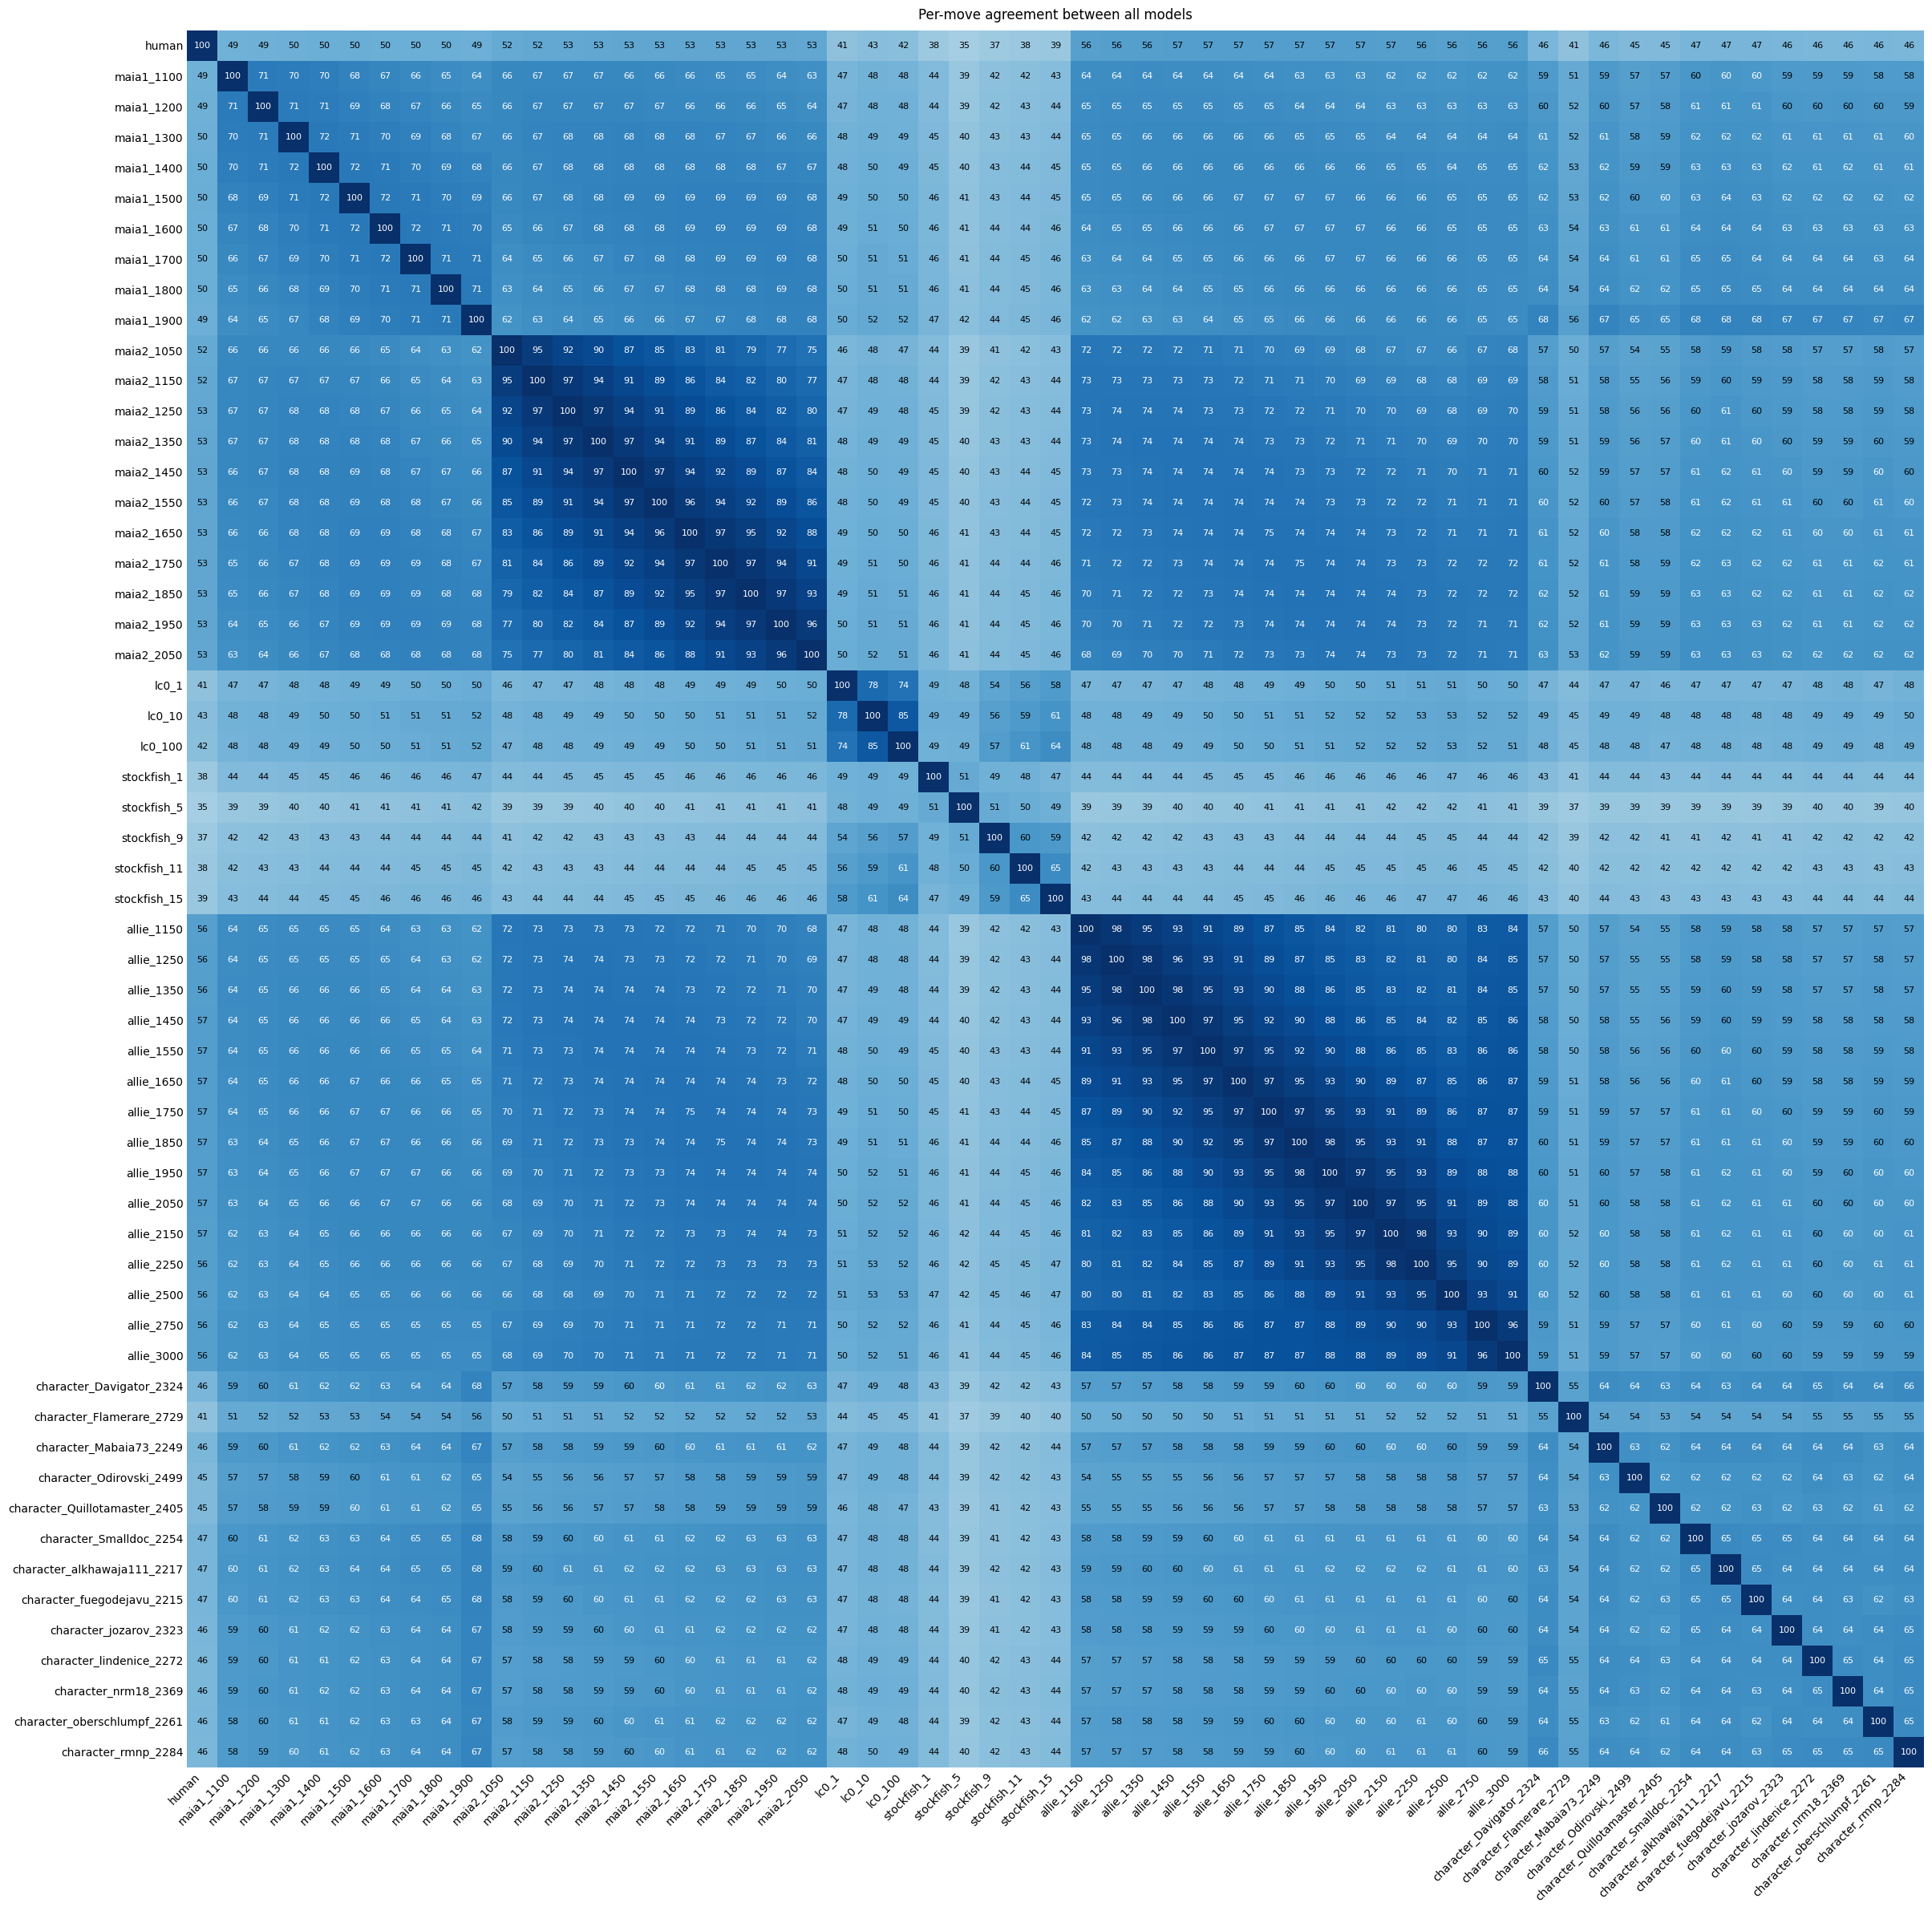

Saved: /home/jovyan/artem/chess-fraud/reports/01_per_move_agreement/plots/full_heatmap.png


In [9]:
(OUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "plots" / "full_heatmap.png"

plot_agreement_heatmap(
    agreement_df,
    title="Per-move agreement between all models",
    out_path=OUT_PNG,
    show_values=True,
    figsize=(24, 24)
)

print("Saved:", OUT_PNG)